In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/home-dataset/home.txt")
df.head()

,2104,3,399900
0,1600,3,329900
1,2400,3,369000
2,1416,2,232000
3,3000,4,539900
4,1985,4,299900


In [3]:
df.columns

Index(['2104', '3', '399900'], dtype='object')

In [4]:
df["Area"] = df["2104"]
df['Bedroom'] = df["3"]
df['Price'] = df['399900']
df.drop(df.columns[[0,1,2]],axis=1, inplace=True)

In [5]:
df.columns

Index(['Area', 'Bedroom', 'Price'], dtype='object')

In [6]:
df.shape

(46, 3)

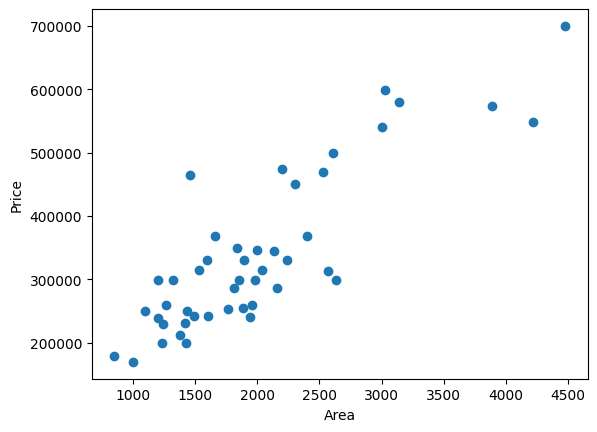

In [7]:
plt.scatter(df['Area'],df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

**Pearson Correlation:** 


![Pearson Correlation](https://miro.medium.com/v2/resize:fit:1400/1*ySKWb-A39_xgH7HdGDwQ3Q.png)The Pearson correlation measures the strength of the linear relationship between two variables. It has a value between -1 to 1, with a value of -1 meaning a total negative linear correlation, 0 being no correlation, and + 1 meaning a total positive correlation.

In [8]:
df.corr()

,Area,Bedroom,Price
Area,1.000000,0.561030,0.855928
Bedroom,0.561030,1.000000,0.445994
Price,0.855928,0.445994,1.000000


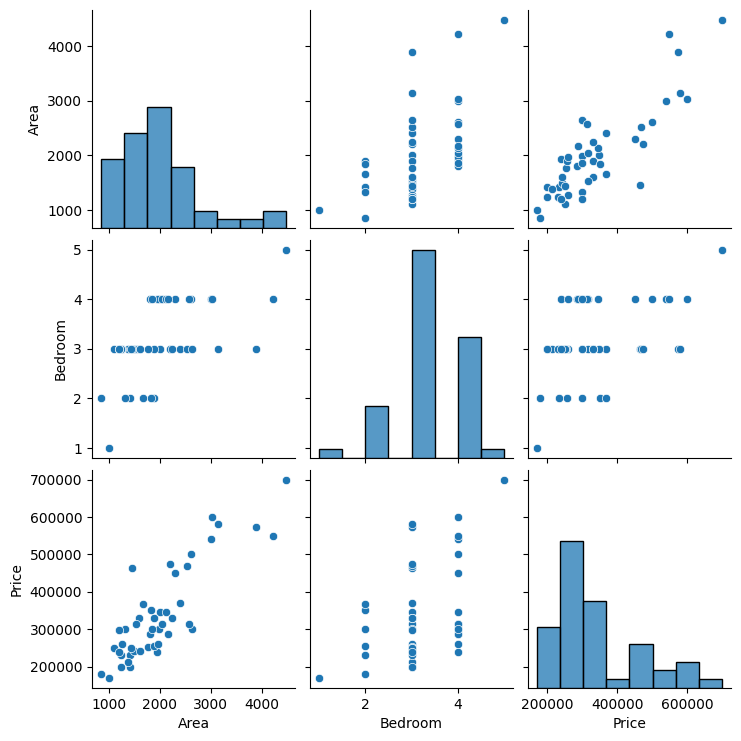

In [9]:
# seaborn for visualization
sns.pairplot(df)

It can be observed Area and Price have linear correlation.

In [10]:
# Independent and dependent features
X = df[['Area']] ## single square braces will resut in series. To make the array as 2D i.e. rows with some specific number of columns, we can use double square braces.
y = df['Price'] # this variable can be in 1D or series
X.shape, y.shape

((46, 1), (46,))

In [11]:
np.array(y).shape

(46,)

### Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state= 0) # random_state will ensure that the split wil be done the same way every time 

In [13]:
X_train.shape

(34, 1)

### Standardization

To make all the feature values such that mean(μ) = 0 and standard deviation(σ) = 1 (using z-score method). The formula for calculating a z-score is z = (x-μ)/σ, where x is the raw score, μ is the population mean, and σ is the population standard deviation. ![Z-score](https://www.simplypsychology.org/wp-content/uploads/Z-score-formula.jpg)
* A positive z-score indicates the raw score is higher than the mean average. For example, if a z-score is equal to +1, it is 1 standard deviation above the mean.
* A negative z-score reveals the raw score is below the mean average. For example, if a z-score is equal to -2, it is two standard deviations below the mean.

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(X_train)

array([[-0.91304153],
       [-0.66588425],
       [-0.90960879],
       [ 1.18207412],
       [-0.77573193],
       [ 0.23120514],
       [-0.87184865],
       [ 0.65114366],
       [ 0.27468651],
       [-0.57663301],
       [-0.83523276],
       [-0.53086315],
       [ 0.69920202],
       [-0.21390682],
       [ 0.3456298 ],
       [ 2.53686217],
       [-0.70707713],
       [-0.86841591],
       [ 0.46005447],
       [ 0.60422955],
       [ 2.83779904],
       [-0.64185507],
       [-1.0274662 ],
       [-0.65329754],
       [ 2.164982  ],
       [ 0.15339636],
       [-0.45076588],
       [-0.26425367],
       [-0.066299  ],
       [-0.38211108],
       [-1.31123937],
       [ 1.14660247],
       [-0.45534287],
       [-0.1669927 ]])

In [15]:
#Apply Simple Linear regression
from sklearn.linear_model import LinearRegression
model1 = LinearRegression(n_jobs = -1) # all the processors will be used for computation if n_jobs is set to -1
model1.fit(X_train,y_train) # here we cannot pass X_train in series format, because it will give error that expected 2D array instead got 1D array/series 

LinearRegression(n_jobs=-1)

In [16]:
model1.coef_,model1.intercept_

(array([136.67450355]), 69335.20511143858)

* Here, coefficient gives the amount of change in Dependent variable(y) for one unit change in Independent variable(X). 
* Intercept gives the the point where the line cuts y-axis for x = 0.
![](https://miro.medium.com/v2/1*csk8XTXy0j__hm_kbkwxCw.jpeg)

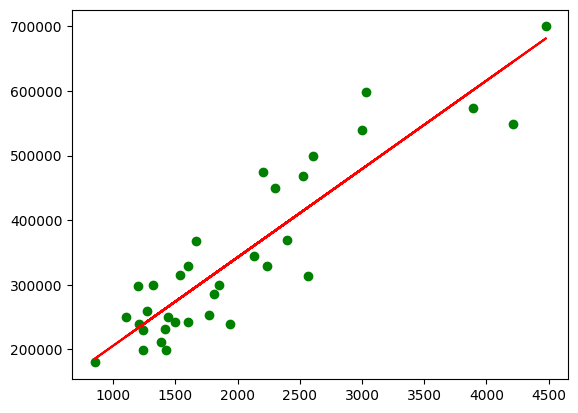

In [17]:
plt.scatter(X_train,y_train,color = 'green')
plt.plot(X_train,model1.predict(X_train),color = 'red')

### Predcition on test data
* predicted Price = intercept + coefficient * Area
* Y_pred_test = 69335.205 + 136.67 * x_test

In [18]:
y_pred = model1.predict(x_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

![R2_score](https://miro.medium.com/v2/resize:fit:1400/1*_HbrAW-tMRBli6ASD5Bttw.png)

In [20]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2_score:",r2_score(y_test,y_pred))

MAE: 65110.74975985964
MSE: 7015870274.169964
R2_score: 0.30584572379011277


![](https://4.bp.blogspot.com/-qEGt3DaQIF0/V2meLITZj3I/AAAAAAAAEp4/WKCs0FrI1JsovDMwaw1r1iUboULfRI7MwCLcB/s1600/stb1.png)

In [21]:
adjusted_r2 = 1 - ((1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test))-x_test.shape[1]-1)
adjusted_r2

2.36369191347427